In [30]:
import pandas as pd
import numpy as np
import scipy.stats as st

fct = pd.read_parquet("data/fct_lap.parquet")
dim_driver = pd.read_parquet("data/dim_driver.parquet")
dim_session = pd.read_parquet("data/dim_session.parquet")
dim_team = pd.read_parquet("data/dim_team.parquet")
dim_compound = pd.read_parquet("data/dim_compound.parquet")

In [31]:
print(fct.dtypes)

time                    timedelta64[ns]
lap_time                timedelta64[ns]
lap_number                        Int64
stint                             Int64
pit_out_time            timedelta64[ns]
pit_in_time             timedelta64[ns]
sector1_time            timedelta64[ns]
sector2_time            timedelta64[ns]
sector3_time            timedelta64[ns]
sector1_session_time    timedelta64[ns]
sector2_session_time    timedelta64[ns]
sector3_session_time    timedelta64[ns]
speed_i1                        float64
speed_i2                        float64
speed_fl                        float64
speed_st                        float64
is_personal_best                 object
tyre_life                         Int64
fresh_tyre                         bool
lap_start_time          timedelta64[ns]
lap_start_date           datetime64[ns]
track_status                     object
position                          Int64
deleted                          object
deleted_reason                   object


In [32]:
pace = fct[fct["is_pace_lap"]].copy()
pace['lap_time_s'] = pace["lap_time"].dt.total_seconds()
print(len(pace))
pace

4902


,time,lap_time,lap_number,stint,pit_out_time,pit_in_time,sector1_time,sector2_time,sector3_time,sector1_session_time,...,team_key,driver_key,compound_key,session_key,is_first_lap,is_in_lap,is_out_lap,is_not_green,is_pace_lap,lap_time_s
1,0 days 00:59:58.605000,0 days 00:01:23.412000,2,1,NaT,NaT,0 days 00:00:29.364000,0 days 00:00:32.600000,0 days 00:00:21.448000,0 days 00:59:04.573000,...,1,3,2,1,False,False,False,False,True,83.412
3,0 days 01:02:44.094000,0 days 00:01:22.787000,4,1,NaT,NaT,0 days 00:00:28.845000,0 days 00:00:32.551000,0 days 00:00:21.391000,0 days 01:01:50.168000,...,1,3,2,1,False,False,False,False,True,82.787
4,0 days 01:04:06.632000,0 days 00:01:22.538000,5,1,NaT,NaT,0 days 00:00:28.826000,0 days 00:00:32.294000,0 days 00:00:21.418000,0 days 01:03:12.936000,...,1,3,2,1,False,False,False,False,True,82.538
6,0 days 01:06:57.942000,0 days 00:01:22.981000,7,1,NaT,NaT,0 days 00:00:28.977000,0 days 00:00:32.542000,0 days 00:00:21.462000,0 days 01:06:03.954000,...,1,3,2,1,False,False,False,False,True,82.981
7,0 days 01:08:20.952000,0 days 00:01:23.010000,8,1,NaT,NaT,0 days 00:00:28.925000,0 days 00:00:32.704000,0 days 00:00:21.381000,0 days 01:07:26.883000,...,1,3,2,1,False,False,False,False,True,83.010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5618,0 days 02:18:45.302000,0 days 00:01:28.723000,53,3,NaT,NaT,0 days 00:00:17.776000,0 days 00:00:38.507000,0 days 00:00:32.440000,0 days 02:17:34.429000,...,2,16,2,5,False,False,False,False,True,88.723
5619,0 days 02:20:13.982000,0 days 00:01:28.680000,54,3,NaT,NaT,0 days 00:00:17.875000,0 days 00:00:38.411000,0 days 00:00:32.394000,0 days 02:19:03.251000,...,2,16,2,5,False,False,False,False,True,88.680
5620,0 days 02:21:42.552000,0 days 00:01:28.570000,55,3,NaT,NaT,0 days 00:00:17.709000,0 days 00:00:38.457000,0 days 00:00:32.404000,0 days 02:20:31.765000,...,2,16,2,5,False,False,False,False,True,88.570
5621,0 days 02:23:11.492000,0 days 00:01:28.940000,56,3,NaT,NaT,0 days 00:00:17.865000,0 days 00:00:38.471000,0 days 00:00:32.604000,0 days 02:22:00.491000,...,2,16,2,5,False,False,False,False,True,88.940


In [33]:
pace.groupby(['driver_key', 'session_key'])["lap_time_s"].std()

driver_key  session_key
1           1              0.612838
            2              0.575727
            3              1.069451
            4              1.119236
            5              1.050204
                             ...   
20          1                   NaN
            2              0.573979
            3              0.961474
            4              1.473241
            5              0.859495
Name: lap_time_s, Length: 96, dtype: float64

In [34]:
counts = pace.groupby(["driver_key", "session_key"])["lap_time_s"].count()
print(counts.sort_values().head(10))

driver_key  session_key
20          1               1
19          4               5
            1              21
8           2              24
12          3              27
18          1              28
4           4              32
9           3              42
20          3              42
16          3              42
Name: lap_time_s, dtype: int64


<Axes: xlabel='count', ylabel='std'>

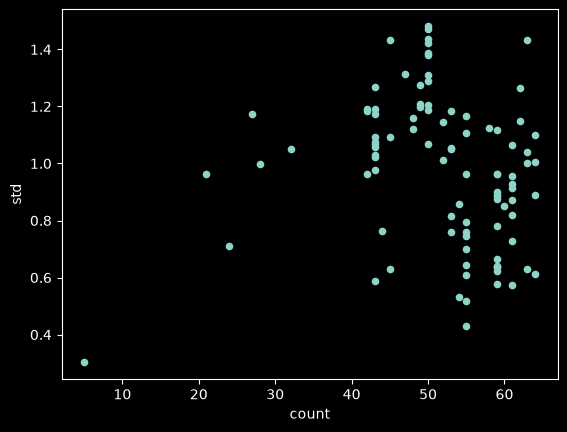

In [35]:
stats = pace.groupby(["driver_key", "session_key"])["lap_time_s"].agg(["count", "std"]).reset_index()
stats.plot.scatter(x="count", y="std")

In [36]:
print((stats["count"] < 40).sum())
print((stats["count"] < 30).sum())

7
6


In [37]:
stats = pace.groupby(["driver_key", "session_key"])["lap_time_s"].agg(["count", "std"]).reset_index()
stats = stats[stats["count"] >= 40]
print(len(stats))

89


In [38]:
stats = stats.merge(dim_driver[["driver_key","driver_code"]], on="driver_key", how="left")
stats = stats.merge(dim_session[["session_key","event_name"]], on="session_key", how="left")

stats

,driver_key,session_key,count,std,driver_code,event_name
0,1,1,64,0.612838,NOR,Mexico City Grand Prix
1,1,2,59,0.575727,NOR,São Paulo Grand Prix
2,1,3,43,1.069451,NOR,Las Vegas Grand Prix
3,1,4,48,1.119236,NOR,Qatar Grand Prix
4,1,5,53,1.050204,NOR,Abu Dhabi Grand Prix
...,...,...,...,...,...,...
84,19,5,53,1.184147,HUL,Abu Dhabi Grand Prix
85,20,2,61,0.573979,LAW,São Paulo Grand Prix
86,20,3,42,0.961474,LAW,Las Vegas Grand Prix
87,20,4,50,1.473241,LAW,Qatar Grand Prix


               event_name      mean
4    São Paulo Grand Prix  0.782985
0    Abu Dhabi Grand Prix  0.842826
2  Mexico City Grand Prix  0.987851
1    Las Vegas Grand Prix  1.021724
3        Qatar Grand Prix  1.296796


<Axes: xlabel='mean', ylabel='event_name'>

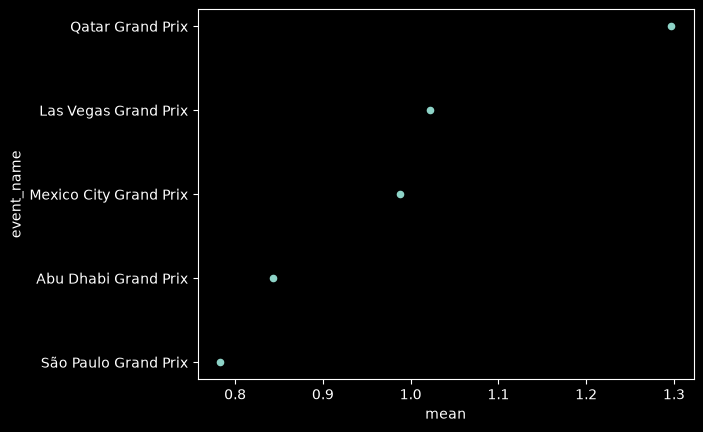

In [39]:
statscheck = stats.groupby(["event_name"])["std"].agg(["mean"]).reset_index().sort_values("mean")
print(statscheck)
statscheck.plot.scatter(x="mean", y="event_name")

In [40]:
print(dim_driver)
print(dim_session)

    driver_key driver_code        driver_name driver_number   colour  \
0            1         NOR       Lando Norris             4  #f47600   
1            2         LEC    Charles Leclerc            16  #ed1131   
2            3         VER     Max Verstappen             1  #4781d7   
3            4         BEA     Oliver Bearman            87  #9c9fa2   
4            5         PIA      Oscar Piastri            81  #f47600   
5            6         ANT     Kimi Antonelli            12  #00d7b6   
6            7         RUS     George Russell            63  #00d7b6   
7            8         HAM     Lewis Hamilton            44  #ed1131   
8            9         OCO       Esteban Ocon            31  #9c9fa2   
9           10         BOR  Gabriel Bortoleto             5  #01c00e   
10          11         TSU       Yuki Tsunoda            22  #4781d7   
11          12         ALB    Alexander Albon            23  #1868db   
12          13         HAD       Isack Hadjar             6  #6c

index    driver_key driver_code
2            3         VER

index    session_key  round_number
1            2            21                Brazil    São Paulo
3            4            23                 Qatar       Lusail

      lap_number  tyre_life  lap_time_s
3433          34          2      84.845
3434          35          3      84.779
3435          36          4      84.744
3436          37          5      84.618
3437          38          6      84.907
3438          39          7      84.592
3439          40          8      84.541
3440          41          9      84.568
3441          42         10      84.729
3442          43         11      84.747
3443          44         12      84.701
3444          45         13      83.515
3445          46         14      83.887
3446          47         15      83.805
3447          48         16      83.799
3448          49         17      83.665
3449          50         18      83.498
3450          51         19      83.989
3451          52         20      84.141
3452          53         21      84.492
3453          54         22      84.678
3454          55         23      84.405
3455          56         24      84.403
3456          57         25      84.968


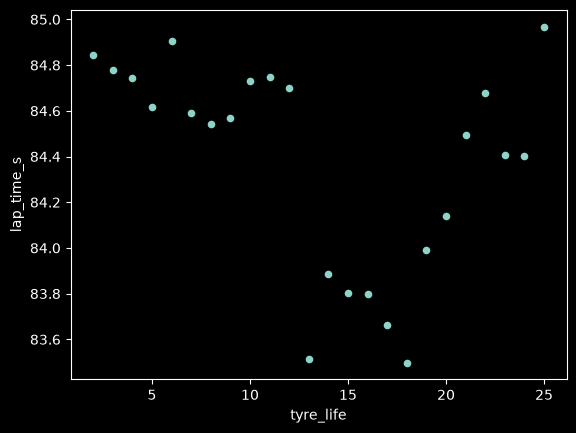

In [41]:
ver = pace[(pace['driver_key'] == 3) & (pace['session_key'] == 4) & (pace['stint'] == 3)].copy()
len(ver)
ver.plot.scatter(x="tyre_life", y="lap_time_s")
print(ver[["lap_number", "tyre_life", "lap_time_s"]].to_string())

<Axes: xlabel='tyre_life', ylabel='lap_time_s'>

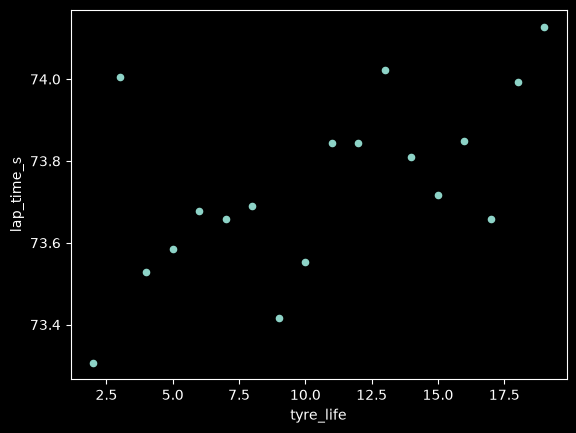

In [42]:
ver = pace[(pace['driver_key'] == 3) & (pace['session_key'] == 2) & (pace['stint'] == 3)].copy()
len(ver)
ver.plot.scatter(x="tyre_life", y="lap_time_s")

In [43]:
ver2 = fct[(fct['driver_key'] == 3) & (fct['session_key'] == 4) & (fct['stint'] == 1)].copy()
len(ver2)

7

In [44]:
compoundxsesh = pace.groupby(["compound_key", "session_key"])["lap_number"].agg(["min", "max", "count"]).reset_index()
print(compoundxsesh)

    compound_key  session_key  min  max  count
0              1            1    2   71    607
1              1            2    9   71    177
2              1            4    2   57     38
3              1            5    2    7     17
4              2            1    2   71    417
5              2            2    9   71    811
6              2            3    5   50    235
7              2            4    2   57    587
8              2            5    2   58    384
9              3            1    2   47     82
10             3            2    9   28     44
11             3            3    4   50    525
12             3            4    2   57    297
13             3            5    2   58    681


In [45]:
stintcheck = pace.groupby(["driver_key", "session_key", "stint"])['lap_number'].agg(["count"]).reset_index()
print(len(stintcheck))
print(stintcheck["count"].sort_values().head(20))

237
227    1
91     3
164    4
30     5
89     5
81     5
43     5
17     5
106    5
113    5
125    5
186    5
137    5
161    5
68     5
94     5
150    5
201    5
173    5
213    5
Name: count, dtype: Int64


In [46]:
print(stintcheck["count"].describe())

count        237.0
mean     20.683544
std       9.526783
min            1.0
25%           15.0
50%           21.0
75%           25.0
max           51.0
Name: count, dtype: Float64


In [47]:
print((stintcheck["count"] >= 10).sum())
print((stintcheck["count"] >= 15).sum())

205
181


In [48]:
from scipy.stats import linregress

In [49]:
result = linregress([1, 2, 3, 4, 5], [10, 12, 14, 16, 18])
print(result)

LinregressResult(slope=np.float64(2.0), intercept=np.float64(8.0), rvalue=np.float64(1.0), pvalue=np.float64(1.2004217548761418e-30), stderr=np.float64(0.0), intercept_stderr=np.float64(0.0))


In [50]:
def count_rows(group):
    return len(group)

print(pace.groupby(["driver_key", "session_key", "stint"]).apply(count_rows))

driver_key  session_key  stint
1           1            1        30
                         2        34
            2            1        21
                         2        18
                         3        20
                                  ..
20          4            1         5
                         2        21
                         3        24
            5            1        19
                         2        35
Length: 237, dtype: int64


C:\Users\davia\AppData\Local\Temp\ipykernel_18984\2931306635.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(pace.groupby(["driver_key", "session_key", "stint"]).apply(count_rows))


In [51]:
def stint_slope(group):
    if len(group) < 10:
        return pd.Series({"slope": float("nan"), "r": float("nan"), "stderr": float("nan")})
    result = linregress(group["tyre_life"], group["lap_time_s"])
    return pd.Series({"slope": result.slope, "r": result.rvalue, "stderr": result.stderr})

slopes = pace.groupby(["driver_key", "session_key", "stint"]).apply(stint_slope, include_groups=False).reset_index()

print(len(slopes))
print(slopes["slope"].isna().sum())
print(slopes["slope"].describe())

237
32
count    205.000000
mean       0.003066
std        0.053567
min       -0.154182
25%       -0.036963
50%        0.006089
75%        0.035129
max        0.242054
Name: slope, dtype: float64


In [52]:
print((slopes["r"].abs() < 0.3).sum())
print(slopes["r"].abs().describe())

49
count    205.000000
mean       0.526037
std        0.267688
min        0.002008
25%        0.305269
50%        0.581121
75%        0.743589
max        0.976742
Name: r, dtype: float64


In [53]:
stint_compound = pace.groupby(["driver_key", "session_key", "stint"])["compound_key"].first().reset_index()
print(len(stint_compound))

237


In [54]:
slopes = slopes.merge(stint_compound, on=["driver_key", "session_key", "stint"], how="left")
slopes

,driver_key,session_key,stint,slope,r,stderr,compound_key
0,1,1,1,0.019433,0.525199,0.005951,1
1,1,1,2,0.006555,0.202895,0.005592,2
2,1,2,1,0.043012,0.708244,0.009836,2
3,1,2,2,0.020215,0.741072,0.004579,1
4,1,2,3,-0.011254,-0.351616,0.007062,2
...,...,...,...,...,...,...,...
232,20,4,1,NaN,NaN,NaN,2
233,20,4,2,-0.042027,-0.797540,0.007293,2
234,20,4,3,-0.087762,-0.873483,0.010429,3
235,20,5,1,0.078249,0.862798,0.011120,2


    compound_key  session_key      mean  count
6              2            3 -0.054286     14
7              2            4 -0.047899     25
11             3            3 -0.043866     19
12             3            4 -0.036375     13
9              3            1 -0.014477      2
2              1            4 -0.005846      1
13             3            5 -0.000218     21
4              2            1  0.012737     16
0              1            1  0.021857     26
8              2            5  0.033908     23
5              2            2  0.045544     34
10             3            2  0.057719      2
1              1            2  0.079538      9
3              1            5       NaN      0


<Axes: xlabel='mean', ylabel='count'>

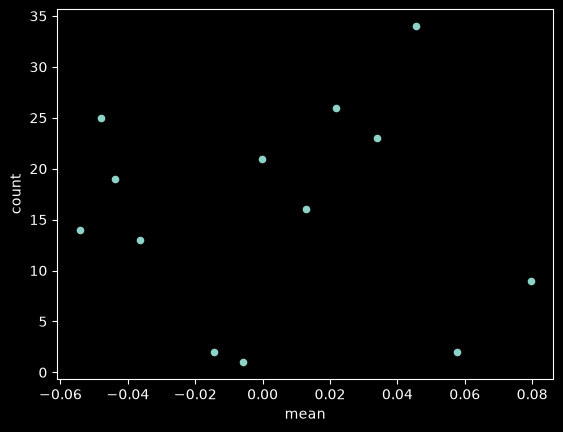

In [55]:
stintscheck = slopes.groupby(["compound_key", "session_key"])["slope"].agg(["mean", "count"]).reset_index().sort_values("mean")
print(stintscheck)
stintscheck.plot.scatter(x="mean", y="count")

In [56]:
stintscheck = stintscheck.merge(dim_compound[["compound_key","compound_name"]], on="compound_key", how="left")
stintscheck = stintscheck.merge(dim_session[["session_key","event_name"]], on="session_key", how="left")
stintscheck = stintscheck[stintscheck['count'] >= 5]

stintscheck

,compound_key,session_key,mean,count,compound_name,event_name
0,2,3,-0.054286,14,MEDIUM,Las Vegas Grand Prix
1,2,4,-0.047899,25,MEDIUM,Qatar Grand Prix
2,3,3,-0.043866,19,HARD,Las Vegas Grand Prix
3,3,4,-0.036375,13,HARD,Qatar Grand Prix
6,3,5,-0.000218,21,HARD,Abu Dhabi Grand Prix
7,2,1,0.012737,16,MEDIUM,Mexico City Grand Prix
8,1,1,0.021857,26,SOFT,Mexico City Grand Prix
9,2,5,0.033908,23,MEDIUM,Abu Dhabi Grand Prix
10,2,2,0.045544,34,MEDIUM,São Paulo Grand Prix
12,1,2,0.079538,9,SOFT,São Paulo Grand Prix


In [57]:
from analysis import load_data, consistency, pace_trend

fct, dim_driver, dim_session, dim_team, dim_compound = load_data()
print(len(consistency(fct, dim_driver, dim_session)))
print(pace_trend(fct, dim_compound, dim_session))


print(len(consistency(fct, dim_driver, dim_session)))
print(consistency(fct, dim_driver, dim_session).head())


c = consistency(fct, dim_driver, dim_session)
print(c.groupby("event_name")["resid_sd"].mean().sort_values())

KeyError: "Column(s) ['n', 'resid_sd', 'slope'] do not exist"

In [58]:
from analysis import load_data, stint_laps
fct, dim_driver, dim_session, dim_team, dim_compound = load_data()
print(len(stint_laps(fct, 3, 4, 3)))

24


In [59]:
pace = fct[fct["is_pace_lap"]].copy()
pace["lap_time_s"] = pace["lap_time"].dt.total_seconds()

In [60]:
def prepare_laps(fct, k=0.03, fuel_kg=100):
    pace = fct[fct["is_pace_lap"]].copy()
    pace["lap_time_s"] = pace["lap_time"].dt.total_seconds()
    total_laps = fct.groupby(["session_key"])["lap_number"].max().reset_index()
    total_laps = total_laps.rename(columns={"lap_number": "race_laps"})

    pace = pace.merge(total_laps, on=["session_key"], how="left")
    pace["lap_burn_rate"] = fuel_kg / pace["race_laps"]
    pace["fuel_burned"] = pace["lap_burn_rate"] * pace["lap_number"]
    pace["lap_time_corrected"] = pace["lap_time_s"] + k * pace["fuel_burned"]

    return pace

In [61]:
p = prepare_laps(fct)
print(p[["session_key", "lap_number", "race_laps", "fuel_burned", "lap_time_s", "lap_time_corrected"]].head())

   session_key  lap_number  race_laps  fuel_burned  lap_time_s  \
0            1           2         71     2.816901      83.412   
1            1           4         71     5.633803      82.787   
2            1           5         71     7.042254      82.538   
3            1           7         71     9.859155      82.981   
4            1           8         71    11.267606      83.010   

   lap_time_corrected  
0           83.496507  
1           82.956014  
2           82.749268  
3           83.276775  
4           83.348028  


In [ ]:
from analysis import load_data, consistency, pace_trend, stint_laps

fct, dim_driver, dim_session, dim_team, dim_compound = load_data()
print(pace_trend(fct, dim_compound, dim_session))

In [ ]:
from analysis import load_data, consistency, pace_trend, stint_laps, stint_fits, prepare_laps
s = stint_fits(fct)
print(s[(s["driver_key"] == 3) & (s["session_key"] == 2)])


p = prepare_laps(fct)
v = p[(p["driver_key"] == 3) & (p["session_key"] == 2)]
print(v.groupby("stint")["lap_number"].agg(["count", "min", "max"]))


In [ ]:
f = fct[(fct["driver_key"] == 3) & (fct["session_key"] == 2)]
print(f[f["lap_number"] <= 10][["lap_number", "stint", "track_status", "is_first_lap", "is_in_lap", "is_out_lap", "is_not_green", "is_pace_lap"]].to_string())
print(v[v["lap_time_corrected"] < 74][["lap_number", "stint", "tyre_life", "lap_time_s", "lap_time_corrected", "track_status"]].to_string())

In [ ]:
s = stint_fits(fct)
print(s[(s["driver_key"] == 3) & (s["session_key"] == 2)])

In [ ]:
print(pace_trend(fct, dim_compound, dim_session))
c = consistency(fct, dim_driver, dim_session)
print(c.groupby("event_name")["resid_sd"].mean().sort_values())

In [ ]:
s = stint_fits(fct)
lv = s[s["session_key"] == 3]
print(len(lv))
print(lv["n"].describe())
print(lv["n"].isna().sum())

In [ ]:
f = fct[fct["session_key"] == 3]
print(len(f))
print(f["track_status"].value_counts())
print(f["is_pace_lap"].sum())

In [ ]:
c_raw = stint_fits(fct).groupby(["driver_key", "session_key"]).agg({"resid_sd": "mean", "n": "sum"}).reset_index()
print(c_raw.groupby("session_key")["n"].describe())

In [ ]:
c = consistency(fct, dim_driver, dim_session)
print(len(c))
print(c.groupby("event_name").size())
print(c.groupby("event_name")["resid_sd"].mean().sort_values())


In [62]:
s = pd.read_parquet("data/stint_fits.parquet")
print(s[s["stint"] == 1]["n"].describe())

count    87.000000
mean     14.413793
std       9.739099
min       3.000000
25%       6.000000
50%      14.000000
75%      19.000000
max      42.000000
Name: n, dtype: float64
